In [1]:
%%capture

import os
from pathlib import Path

project_root = "."
i=0
try:
    os.chdirdir(project_root)
    assert Path('.gitignore').is_file()
except:
    while i<4 and (not Path('.gitignore').is_file()):
        os.chdir(Path(Path.cwd(), '../'))
        i+=1
    project_root = Path.cwd()
print(Path.cwd())

In [4]:
import pandas as pd
import numpy as np
# from scipy.signal import argrelextrema
# from sklearn.linear_model import LinearRegression
# from datetime import datetime, date, timedelta, timezone, time
import talib.abstract as ta
# import seaborn as sns
# import matplotlib.pyplot as plt
import freqtrade.vendor.qtpylib.indicators as qtpylib
from freqtrade.strategy import merge_informative_pair
from freqtrade.configuration import Configuration
from freqtrade.data.btanalysis import load_backtest_data
import json

In [6]:
%%capture
ticker = 'BTC'
config = Configuration.from_files(["user_data/config.json"])
config["timeframe"] = "1h"
config["strategy"] = "AtlasEngine"
data_location = config["datadir"]
pair = f"{ticker}/USDT:USDT"
backtest_dir = config["user_data_dir"] / "backtest_results"
base_url = "/home/mo/Repositories/trade/user_data/data/bybit/futures/"
dataframe_15m = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-15m-futures.feather")
dataframe_1h = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-1h-futures.feather")
dataframe_4h = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-4h-futures.feather")
dataframe_1d = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-1d-futures.feather")

In [15]:
%%capture
trades = load_backtest_data(backtest_dir)
trades['color'] = np.where(trades.profit_abs >= 0, 'green', 'red')

In [14]:
def extract_features(dataframe, c1, c2, col, name, tt=0, pt=0, d="forward"):
    
    df = dataframe.copy()

    starts = df.loc[c1].reset_index().rename(columns={"index": "start"})
    ends   = df.loc[c2].reset_index().rename(columns={"index": "end"})

    if starts.empty or ends.empty:
        dataframe[name] = np.nan
        dataframe[f"{name}_index_dist"] = np.nan
        dataframe[f"{name}_price_dist"] = np.nan
        return dataframe

    pairs = pd.merge_asof(
        starts[['start']].sort_values("start"),
        ends[['end']].sort_values("end"),
        left_on="start",
        right_on="end",
        direction=d,
    ).dropna()[["start", "end"]]

    if pairs.empty:
        dataframe[name] = np.nan
        dataframe[f"{name}_index_dist"] = np.nan
        dataframe[f"{name}_price_dist"] = np.nan
        return dataframe

    intervals = pd.IntervalIndex.from_arrays(pairs["start"], pairs["end"], closed="both")
    df["range_id"] = pd.cut(df.index, intervals)

    e = 'max' if col == 'high' else 'min'
    group = df.groupby("range_id", observed=True)
    df[name] = group[col].transform(e)

    df[f"{name}_index_dist"] = group.cumcount() + 1
    df[f"{name}_index_dist"] = group[f"{name}_index_dist"].transform('max')

    hi = group['high'].transform('max')
    lo = group['low'].transform('min')
    df[f"{name}_price_dist"] = np.abs(hi - lo)

    df.loc[
        (df[col] != df[name]),
        [name, f"{name}_index_dist", f"{name}_price_dist"]
    ] = np.nan

    dataframe = dataframe.merge(df[[name, f"{name}_index_dist", f"{name}_price_dist"]],
                        left_index=True, right_index=True, how="left")

    c1 = (dataframe[f'{name}_index_dist'] >= tt)
    c2 = (dataframe[f'{name}_price_dist'] >= dataframe['close'] * pt)
    dataframe[name] = np.where((c1 & c2), dataframe[name], np.nan)
    
    return dataframe

In [16]:
with open('user_data/strategies/atlas_engine.json', mode="r") as file:
    conf = json.load(file)
values = conf.get('params').get('buy')

In [26]:
low = values.get("low")
medium = values.get("medium")
high = values.get("high")

dataframe = dataframe_15m.copy()
dataframe[f'sma_{low}'] = ta.SMA(dataframe["close"], timeperiod=low)
dataframe['atr'] = ta.ATR(dataframe, timeperiod=14)
dataframe['atr_sma_low'] = ta.SMA(dataframe['atr'], timeperiod=10)
dataframe['atr_sma_medium'] = ta.SMA(dataframe['atr'], timeperiod=50)

informative = dataframe_1h.copy()
informative[f'sma_{medium}'] = ta.SMA(informative["close"], timeperiod=medium)
informative['atr'] = ta.ATR(informative, timeperiod=14)
dataframe = merge_informative_pair(dataframe, informative, '15m', '1h', ffill=True)

informative = dataframe_4h.copy()
informative[f'sma_{high}'] = ta.SMA(informative["close"], timeperiod=high)
informative['atr'] = ta.ATR(informative, timeperiod=14)
dataframe = merge_informative_pair(dataframe, informative, '15m', '4h', ffill=True)

sma1 = f"sma_{low}"
sma2 = f"sma_{medium}_1h"

c1 = qtpylib.crossed_above(dataframe[sma1], dataframe[sma2])
c2 = qtpylib.crossed_below(dataframe[sma1], dataframe[sma2])
dataframe = extract_features(dataframe, c1, c2, "high", "max_high")
dataframe = extract_features(dataframe, c2, c1, "low", "min_low")

In [ ]:
plot.plot(
    dataframe,
    # trades,
    p1=[
        ('close','lines','blue'),
        ('max_high','markers','orange'),
        ('min_low','markers','orange'),
        (f'sma_{low}','lines','green'),
        (f'sma_{medium}_1h','lines','red'),
        (f'sma_{high}_4h','lines','grey'),
    ], 
    p2=[
        ('atr','lines','blue'),
        ('atr_1h','lines','green'),
        ('atr_4h','lines','red')
    ],
    # p3=[
    #     ('atr_1h','lines','blue'),
    # ],
    # p4=[
    #     ('atr_4h','lines','blue'),
    # ]
)

In [44]:
c1 = (dataframe.max_high_low == dataframe.max_high_medium)
c2 = (dataframe.max_high_low == dataframe.max_high_high)
c3 = (dataframe.max_high_medium == dataframe.max_high_high)
dataframe.loc[c1 & c2 & c3, "highs"] =  dataframe.loc[c1 & c2 & c3, 'high']

c1 = (dataframe.min_low_low == dataframe.min_low_medium)
c2 = (dataframe.min_low_low == dataframe.min_low_high)
c3 = (dataframe.min_low_medium == dataframe.min_low_high)
dataframe.loc[c1 & c2 & c3, "lows"] =  dataframe.loc[c1 & c2 & c3, 'low']

In [ ]:
import plotly.graph_objects as go

mask = dataframe['max_high_price_dist'].notna()
values = dataframe[mask].max_high_price_dist.values
df = pd.DataFrame(data=values).reset_index(drop=True)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=df.index,
        y=df[0]
    )
)
fig.show()

In [2]:
import technical.indicators as ti

In [7]:
?ti.madrid_sqz

Signature: ti.madrid_sqz(datafame, length=34, src='close', ref=13, sqzLen=5)
Docstring:
Squeeze Madrid Indicator

Author: Creslinux
Original Author: Madrid - Tradingview
https://www.tradingview.com/script/9bUUSzM3-Madrid-Trend-Squeeze/

:param datafame:
:param length: min 14 - default 34
:param src: default close
:param ref: default 13
:param sqzLen: default 5
:return: df['sqz_cma_c'], df['sqz_rma_c'], df['sqz_sma_c']


There are seven colors used for the study

Green : Uptrend in general
Lime : Spots the current uptrend leg
Aqua : The maximum profitability of the leg in a long trade
The Squeeze happens when Green+Lime+Aqua are aligned (the larger the values the better)

Maroon : Downtrend in general
Red : Spots the current downtrend leg
Fuchsia: The maximum profitability of the leg in a short trade
The Squeeze happens when Maroon+Red+Fuchsia are aligned (the larger the values the better)

Yellow : The trend has come to a pause and it is either a reversal warning or a continuation.
The

In [13]:
dataframe = dataframe_1d.copy()
madrid_sqz = ti.madrid_sqz(dataframe)
dataframe['sqz_cma_c'] = madrid_sqz[0].values
dataframe['sqz_rma_c'] = madrid_sqz[1].values
dataframe['sqz_sma_c'] = madrid_sqz[2].values

In [14]:
dataframe

,date,open,high,low,close,volume,sqz_ma,sqz_cma,sqz_rma,sqz_sma,sqz_cma_c,sqz_sma_c,sqz_rma_c
0,2023-12-18 00:00:00+00:00,41395.2,42810.6,40566.0,42683.6,163735.590,NaN,NaN,NaN,NaN,fuchsia,red,maroon
1,2023-12-19 00:00:00+00:00,42683.6,43548.0,41836.4,42298.0,141858.496,NaN,NaN,NaN,NaN,fuchsia,red,maroon
2,2023-12-20 00:00:00+00:00,42298.0,44355.0,42206.3,43710.0,169804.361,NaN,NaN,NaN,NaN,fuchsia,red,maroon
3,2023-12-21 00:00:00+00:00,43710.0,44290.0,43324.3,43902.1,116069.192,NaN,NaN,NaN,NaN,fuchsia,red,maroon
4,2023-12-22 00:00:00+00:00,43902.1,44473.9,43414.1,44010.0,103438.936,NaN,NaN,NaN,NaN,fuchsia,red,maroon
...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,2025-12-31 00:00:00+00:00,88458.0,89194.3,87177.8,87594.9,45406.525,89646.654772,-2051.754772,-1753.333440,-1883.498592,fuchsia,red,maroon
745,2026-01-01 00:00:00+00:00,87594.9,88891.9,87515.0,88810.1,24082.533,89598.851642,-788.751642,-1574.561929,-1486.714189,fuchsia,red,yellow
746,2026-01-02 00:00:00+00:00,88810.1,90958.5,88325.9,89953.8,80011.551,89619.134405,334.665595,-1319.200365,-893.109437,aqua,red,yellow
747,2026-01-03 00:00:00+00:00,89953.8,90706.4,89255.1,90599.9,25358.895,89675.178153,924.721847,-1046.677548,-324.528174,aqua,red,yellow


In [25]:
dataframe = dataframe_1d.copy()
mmar = ti.mmar(dataframe)

In [21]:
dataframe

,date,open,high,low,close,volume,ma05,ma05l,ma10,ma10l,...,leadMA,ma10_c,ma20_c,ma30_c,ma40_c,ma50_c,ma60_c,ma70_c,ma80_c,ma90_c
0,2023-12-18 00:00:00+00:00,41395.2,42810.6,40566.0,42683.6,163735.590,NaN,NaN,NaN,NaN,...,grey,grey,grey,grey,grey,grey,grey,grey,grey,grey
1,2023-12-19 00:00:00+00:00,42683.6,43548.0,41836.4,42298.0,141858.496,NaN,NaN,NaN,NaN,...,grey,grey,grey,grey,grey,grey,grey,grey,grey,grey
2,2023-12-20 00:00:00+00:00,42298.0,44355.0,42206.3,43710.0,169804.361,NaN,NaN,NaN,NaN,...,grey,grey,grey,grey,grey,grey,grey,grey,grey,grey
3,2023-12-21 00:00:00+00:00,43710.0,44290.0,43324.3,43902.1,116069.192,NaN,NaN,NaN,NaN,...,grey,grey,grey,grey,grey,grey,grey,grey,grey,grey
4,2023-12-22 00:00:00+00:00,43902.1,44473.9,43414.1,44010.0,103438.936,43320.740000,NaN,NaN,NaN,...,grey,grey,grey,grey,grey,grey,grey,grey,grey,grey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,2025-12-31 00:00:00+00:00,88458.0,89194.3,87177.8,87594.9,45406.525,87763.156179,87847.284269,87799.446299,87844.901032,...,red,red,red,red,red,red,red,red,red,red
745,2026-01-01 00:00:00+00:00,87594.9,88891.9,87515.0,88810.1,24082.533,88112.137453,87763.156179,87983.201517,87799.446299,...,green,green,green,red,red,red,red,red,red,red
746,2026-01-02 00:00:00+00:00,88810.1,90958.5,88325.9,89953.8,80011.551,88726.024969,88112.137453,88341.492151,87983.201517,...,green,green,green,green,red,red,red,red,red,red
747,2026-01-03 00:00:00+00:00,89953.8,90706.4,89255.1,90599.9,25358.895,89350.649979,88726.024969,88752.111760,88341.492151,...,green,green,green,green,green,red,red,red,red,red


In [26]:
dataframe.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'ma05', 'ma05l',
       'ma10', 'ma10l', 'ma20', 'ma20l', 'ma30', 'ma30l', 'ma40', 'ma40l',
       'ma50', 'ma50l', 'ma60', 'ma60l', 'ma70', 'ma70l', 'ma80', 'ma80l',
       'ma90', 'ma90l', 'ma100', 'ma100l', 'leadMA', 'ma10_c', 'ma20_c',
       'ma30_c', 'ma40_c', 'ma50_c', 'ma60_c', 'ma70_c', 'ma80_c', 'ma90_c'],
      dtype='object')

In [33]:
??ti.mmar

Signature: ti.mmar(dataframe, matype='EMA', src='close', debug=False)
Source:   
def mmar(dataframe, matype="EMA", src="close", debug=False):  # noqa: C901
    """
    Madrid Moving Average Ribbon

    Returns: MMAR
    """
    """
    Author(Freqtrade): Creslinux
    Original Author(TrdingView): "Madrid"

    Pinescript from TV Source Code and Description
    //
    // Madrid : 17/OCT/2014 22:51M: Moving Average Ribbon : 2.0 : MMAR
    // http://madridjourneyonws.blogspot.com/
    //
    // This plots a moving average ribbon, either exponential or standard.
    // This study is best viewed with a dark background.  It provides an easy
    // and fast way to determine the trend direction and possible reversals.
    //
    // Lime : Uptrend. Long trading
    // Green : Reentry (buy the dip) or downtrend reversal warning
    // Red : Downtrend. Short trading
    // Maroon : Short Reentry (sell the peak) or uptrend reversal warning
    //
    // To best determine if this is a reentry point

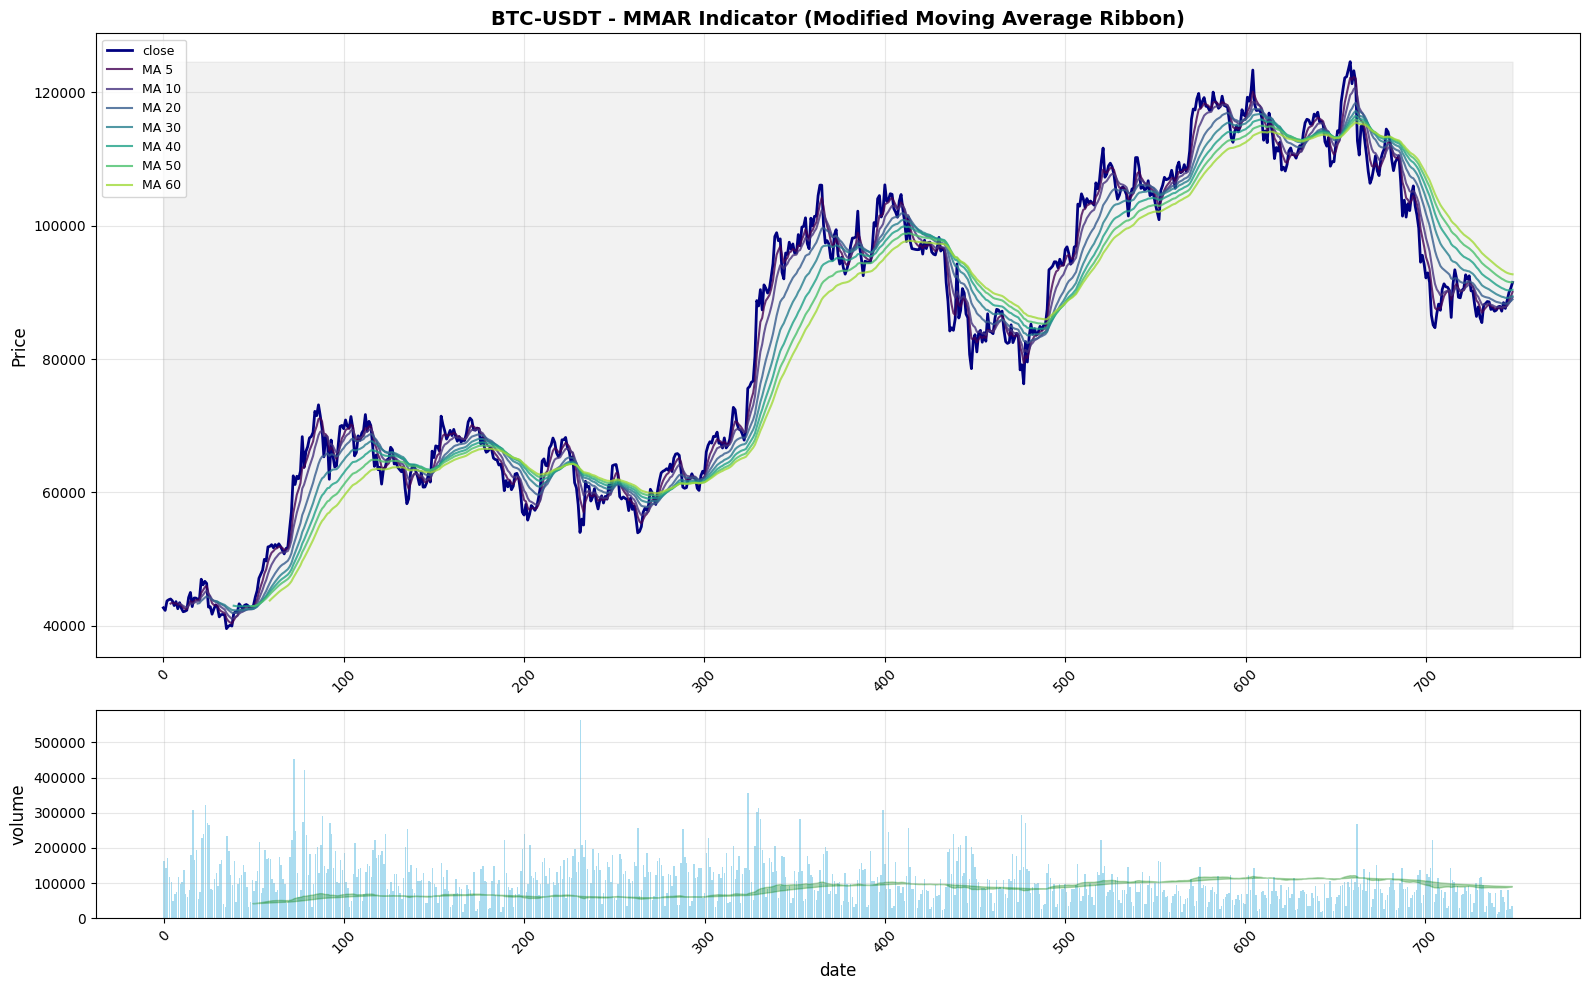


📊 اطلاعات MMAR:
میانگین متحرک 5 دوره‌ای: 90064.00
میانگین متحرک 10 دوره‌ای: 89250.04
میانگین متحرک 20 دوره‌ای: 88948.57
میانگین متحرک 30 دوره‌ای: 89442.07
میانگین متحرک 40 دوره‌ای: 90379.78
میانگین متحرک 50 دوره‌ای: 91523.19
میانگین متحرک 60 دوره‌ای: 92715.06


In [ ]:
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np

# دریافت داده
symbol = "BTC-USDT"  # یا هر نماد دیگر
df = dataframe_1d.copy()

# محاسبه MMAR با تابع اختصاصی
# اگر تابع mmar مستقیم وجود نداشت، می‌توانیم از روش زیر استفاده کنیم:
lengths = [5, 10, 20, 30, 40, 50, 60]
mamode = 'ema'

# ایجاد ستون‌های MMAR
for length in lengths:
    df[f'MA_{length}'] = ta.ema(df['close'], length=length)

# رسم نمودار با جزئیات بیشتر
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                gridspec_kw={'height_ratios': [3, 1]})

# نمودار قیمت و MMAR
ax1.plot(df.index, df['close'], label='close', color='navy', linewidth=2)

# رسم هر خط MMAR با رنگ متفاوت
colormap = plt.cm.viridis
for idx, length in enumerate(lengths):
    color = colormap(idx / len(lengths))
    ax1.plot(df.index, df[f'MA_{length}'], 
             label=f'MA {length}',
             color=color,
             linewidth=1.5,
             alpha=0.8)

ax1.set_title(f'{symbol} - MMAR Indicator (Modified Moving Average Ribbon)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.fill_between(df.index, df['close'].min(), df['close'].max(), 
                  alpha=0.1, color='gray')

# نمودار حجم معاملات
ax2.bar(df.index, df['volume'], color='skyblue', alpha=0.7)
ax2.set_ylabel('volume', fontsize=12)
ax2.set_xlabel('date', fontsize=12)
ax2.grid(True, alpha=0.3)

# چرخش برچسب تاریخ
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)


plt.tight_layout()
plt.show()

# نمایش اطلاعات آماری
print("\n📊 اطلاعات MMAR:")
for length in lengths:
    last_value = df[f'MA_{length}'].iloc[-1]
    print(f'میانگین متحرک {length} دوره‌ای: {last_value:.2f}')

In [7]:
dataframe = dataframe_1d.copy()

In [17]:
dataframe['sma'] = ta.SMA(dataframe['close'], timeperiod=20)
dataframe['gradient'] = dataframe['sma'].diff()
dataframe['sma_gradient'] = ta.SMA(dataframe['gradient'], timeperiod=20)
dataframe

,date,open,high,low,close,volume,sma,gradient,sma_gradient
0,2023-12-18 00:00:00+00:00,41395.2,42810.6,40566.0,42683.6,163735.590,NaN,NaN,NaN
1,2023-12-19 00:00:00+00:00,42683.6,43548.0,41836.4,42298.0,141858.496,NaN,NaN,NaN
2,2023-12-20 00:00:00+00:00,42298.0,44355.0,42206.3,43710.0,169804.361,NaN,NaN,NaN
3,2023-12-21 00:00:00+00:00,43710.0,44290.0,43324.3,43902.1,116069.192,NaN,NaN,NaN
4,2023-12-22 00:00:00+00:00,43902.1,44473.9,43414.1,44010.0,103438.936,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
744,2025-12-31 00:00:00+00:00,88458.0,89194.3,87177.8,87594.9,45406.525,87830.355,-244.440,-108.69225
745,2026-01-01 00:00:00+00:00,87594.9,88891.9,87515.0,88810.1,24082.533,87759.315,-71.040,-126.06775
746,2026-01-02 00:00:00+00:00,88810.1,90958.5,88325.9,89953.8,80011.551,87747.685,-11.630,-135.10825
747,2026-01-03 00:00:00+00:00,89953.8,90706.4,89255.1,90599.9,25358.895,87871.880,124.195,-128.58825


In [9]:
import matplotlib.pyplot as plt

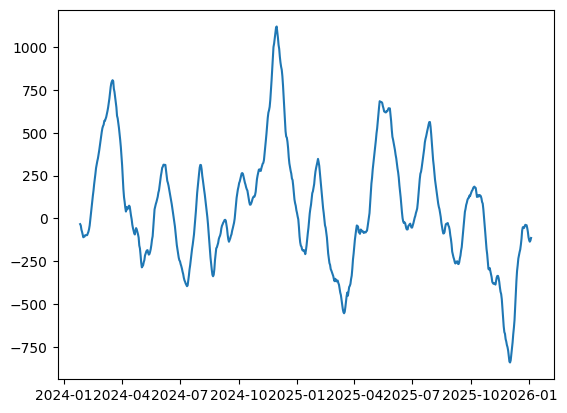

In [18]:
plt.plot(dataframe.date, dataframe.sma_gradient)
plt.show()

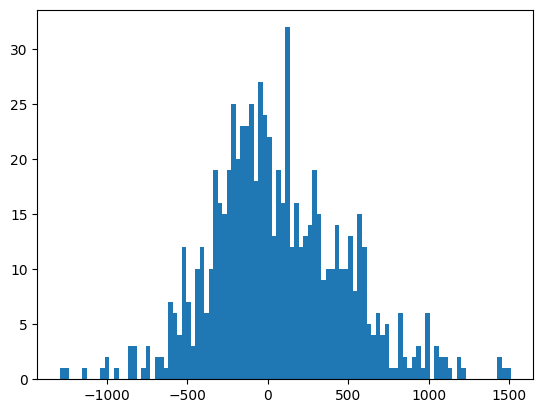

In [20]:
plt.hist(dataframe['gradient'], bins=100)
plt.show()

In [ ]:
dataframe[dataframe['gradient'] > 0]

,date,open,high,low,close,volume,sma,gradient,sma_gradient
